
### Méthodologie : Traitement d'une variable catégorielle à forte cardinalité pour un modèle de churn

#### 🎯 Motivation
Les variables catégorielles avec beaucoup de modalités posent des problèmes :
- Estimations instables pour les modalités rares.
- Explosion dimensionnelle avec one-hot encoding.
- Risque de sur-apprentissage si on utilise le taux brut.

#### ✅ Solution actuarielle : Crédibilité de Bühlmann–Straub
On calcule un **taux crédibilisé** pour chaque modalité :
$
\widehat{p}_g = Z_g \cdot \bar{Y}_g + (1 - Z_g) \cdot \bar{Y}
$
avec :
$
Z_g = \frac{n_g}{n_g + k}, \quad k = \frac{\text{EPV}}{\text{VHM}}
$
- $ n_g $ : effectif de la modalité.
- $\bar{Y}_g $ : taux observé pour la modalité.
- $ \bar{Y} $ : taux global.
- EPV : variance intra-groupe.
- VHM : variance inter-groupe.

#### 🔍 Deux approches possibles
1. **Encodage numérique** : remplacer la modalité par son taux crédibilisé (target encoding régularisé).
2. **Regroupement en classes de risque** : partitionner les taux crédibilisés en 3-4 classes (quantiles ou clustering).

#### 📌 Pourquoi c’est mieux que le regroupement naïf ?
- **Quantitatif** : minimise l’erreur quadratique (MSE) et stabilise les estimations.
- **Business** : segmentation actionnable (faible/moyen/élevé risque) au lieu d’un groupe « Autres » hétérogène.
- Conforme aux normes actuarielles (proportionnalité, traçabilité).

#### ✅ Workflow synthétique
1. Estimer EPV et VHM → calculer $ k $.
2. Calculer $ Z_g $ et le taux crédibilisé pour chaque modalité.
3. **Option A** : utiliser le taux crédibilisé comme variable numérique.
4. **Option B** : créer des classes de risque à partir du taux crédibilisé.
---


In [34]:
!pip install matplotlib
!pip install seaborn

In [2]:
import os
import numpy as np
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [36]:
!pip install fsspec
!pip install s3fs

In [37]:
# instantiate the df_conso_brut DataFrame
df_portefeuille = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")
df_portefeuille.head()

/tmp/ipykernel_180922/980438067.py:2: DtypeWarning: Columns (31,33) have mixed types. Specify dtype option on import or set low_memory=False.
  df_portefeuille = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_portefeuille_2023_11.csv", sep=";")


,client_code,client_age_souscripteur,client_sexe_souscripteur,client_ro_souscripteur,client_code_postal,client_departement,client_departement_avant_changement_12_mois,client_a_conjoint,client_nb_enfants,client_structure_familiale,...,courtier_code_avant_changement_12_mois,courtier_reseau_courtage,courtier_segmentation_interne,courtier_type_commission,courtier_est_escompte,courtier_nb_affaires_n_moins1,courtier_nb_radiations_n_moins1,courtier_nb_affaires_n_moins2,courtier_nb_radiations_n_moins2,target_resiliation_6mois
0,21736,97,F,SS,69100,69,NaN,0.0,0.0,femme ss enfant,...,NaN,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0
1,22037,95,F,SS,26230,26,NaN,0.0,0.0,femme ss enfant,...,140183.0,AFFAIRE DIRECTE,Alptis,NaN,0,51,26,48,21,0
2,22331,88,M,TNS,69760,69,NaN,1.0,0.0,couple ss enfant,...,NaN,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0
3,22604,95,F,TNS,69003,69,NaN,0.0,0.0,femme ss enfant,...,140484.0,AFFAIRE DIRECTE,Alptis,NaN,0,51,26,48,21,0
4,22702,90,M,TNS,69100,69,NaN,1.0,0.0,couple ss enfant,...,NaN,AFFAIRE DIRECTE,Alptis,NaN,0,5,44,3,51,0


In [38]:
# Size of data
df_portefeuille.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132576 entries, 0 to 132575
Data columns (total 47 columns):
 #   Column                                       Non-Null Count   Dtype  
---  ------                                       --------------   -----  
 0   client_code                                  132576 non-null  int64  
 1   client_age_souscripteur                      132576 non-null  int64  
 2   client_sexe_souscripteur                     132576 non-null  object 
 3   client_ro_souscripteur                       132576 non-null  object 
 4   client_code_postal                           132576 non-null  int64  
 5   client_departement                           132576 non-null  int64  
 6   client_departement_avant_changement_12_mois  465 non-null     float64
 7   client_a_conjoint                            132576 non-null  float64
 8   client_nb_enfants                            132576 non-null  float64
 9   client_structure_familiale                   132576 non-nul

In [39]:
# Liste des champs
list_fields = list(df_portefeuille.columns)
list_fields

['client_code',
 'client_age_souscripteur',
 'client_sexe_souscripteur',
 'client_ro_souscripteur',
 'client_code_postal',
 'client_departement',
 'client_departement_avant_changement_12_mois',
 'client_a_conjoint',
 'client_nb_enfants',
 'client_structure_familiale',
 'client_nb_assures_contrat',
 'client_a_garantie_prevoyance',
 'client_produit',
 'client_garantie_base',
 'client_garantie_base_plus_options',
 'client_millesime_tarifaire_produit',
 'client_zone_tarifaire',
 'client_type_zone_tarifaire',
 'client_est_contrat_madelin',
 'client_date_debut_effet_garantie',
 'client_anciennete_contrat_annees',
 'client_cotisations_annualisees_n_moins2',
 'client_cotisations_annualisees_n_moins1',
 'client_cotisations_annualisees_n',
 'client_cotisations_annualisees_n_plus1',
 'client_mode_paiement',
 'client_frequence_paiement',
 'client_nom_banque',
 'client_nps_date_reponse_n',
 'client_nps_note_reco_n',
 'client_nps_verbatim_n',
 'client_nps_date_reponse_n_moins1',
 'client_nps_note_re

In [40]:
#Colonnes avec valeurs manquantes (NaN)
missing_counts = df_portefeuille.isna().mean()
missing_counts = missing_counts[missing_counts > 0]
for col, count in missing_counts.items():
    print(f"{col}: {count}")

client_departement_avant_changement_12_mois: 0.9964925778421434
client_cotisations_annualisees_n_moins2: 0.45913287472845765
client_cotisations_annualisees_n_moins1: 0.2844179942070963
client_nom_banque: 0.026143495051894762
client_nps_date_reponse_n: 0.9436097031136857
client_nps_note_reco_n: 0.9436097031136857
client_nps_verbatim_n: 0.9551427105961864
client_nps_date_reponse_n_moins1: 0.9583936760801351
client_nps_note_reco_n_moins1: 0.9583936760801351
client_nps_verbatim_n_moins1: 0.9670226888727975
courtier_code_avant_changement_12_mois: 0.9410451363746077
courtier_type_commission: 0.2630340333091962


In [41]:
# Décomposition categorical and numerical variables
categorical = df_portefeuille.select_dtypes(include=["object","bool"]).columns.to_list()
numerical = df_portefeuille.select_dtypes(exclude=["object","bool"]).columns.to_list()

In [42]:
# Décomposition categorical and numerical variables
df_cat = df_portefeuille[categorical]
df_cat.nunique()

client_sexe_souscripteur                 2
client_ro_souscripteur                  19
client_structure_familiale              21
client_produit                          46
client_garantie_base                   206
client_garantie_base_plus_options      436
client_millesime_tarifaire_produit      25
client_zone_tarifaire                  173
client_type_zone_tarifaire              51
client_date_debut_effet_garantie      5765
client_mode_paiement                     4
client_frequence_paiement                4
client_nom_banque                      183
client_nps_date_reponse_n              258
client_nps_verbatim_n                 5467
client_nps_date_reponse_n_moins1       262
client_nps_verbatim_n_moins1          4066
courtier_reseau_courtage                 4
courtier_segmentation_interne           17
courtier_type_commission                 4
dtype: int64

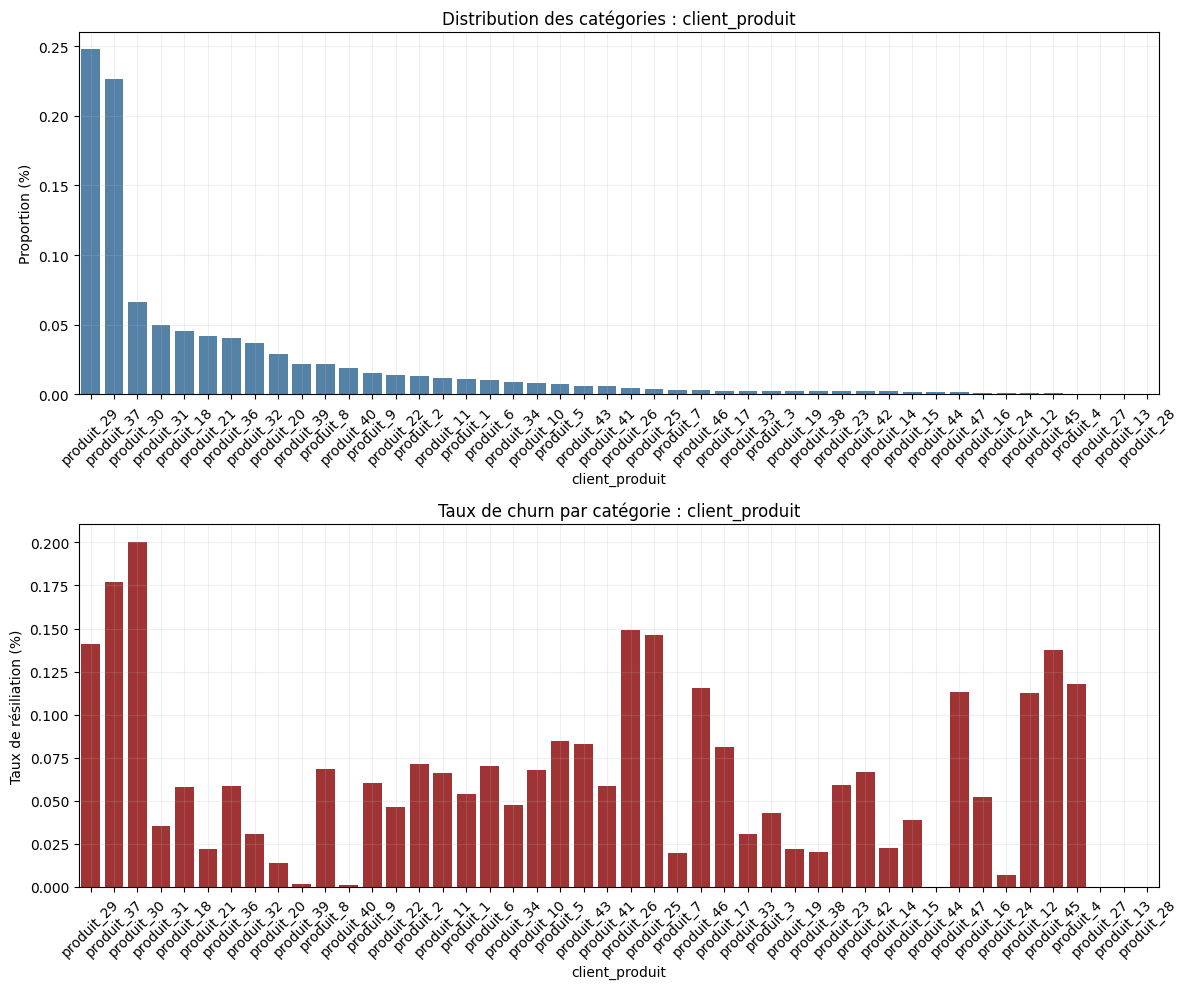

In [43]:
col = "client_produit"  

# Distribution
dist = df_portefeuille[col].value_counts(normalize=True).sort_values(ascending=False)

# Taux de churn
churn = df_portefeuille.groupby(col)["target_resiliation_6mois"].mean().loc[dist.index]

plt.figure(figsize=(12,10))

# ---- PLOT 1 : distribution des modalités  ----
plt.subplot(2,1,1)
sns.barplot(x=dist.index, y=dist.values, color="steelblue")
plt.title(f"Distribution des catégories : {col}")
plt.ylabel("Proportion (%)")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)

# ---- PLOT 2 : taux de churn par modalité ----
plt.subplot(2,1,2)
sns.barplot(x=churn.index, y=churn.values, color="firebrick")
plt.title(f"Taux de churn par catégorie : {col}")
plt.ylabel("Taux de résiliation (%)")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [44]:
df_portefeuille.shape


(132576, 47)

In [45]:
def credibility_buhlmann_straub(df, group_col, target_col):
    """
    Calcule la crédibilité Bühlmann–Straub pour chaque modalité d'une variable catégorielle.

    Paramètres
    ----------
    df : pandas.DataFrame
        Base contenant les observations.
    group_col : str
        Nom de la variable catégorielle (ex: 'client_produit').
    target_col : str
        Nom de la variable cible binaire (0/1).

    Retour
    ------
    result : dict
        {
            'k' : paramètre k,
            'EPV' : Expected Process Variance,
            'VHM' : Variance of Hypothetical Means,
            'taux_global' : p,
            'details' : DataFrame par modalité
                        (n, y, rate, Z, taux_credibilise)
        }
    """

    # ---------- 1. Agrégation ----------
    grp = df.groupby(group_col)[target_col].agg(['sum', 'count'])
    grp = grp.rename(columns={'sum': 'y', 'count': 'n'})
    grp['rate'] = grp['y'] / grp['n']

    # ---------- 2. Taux global ----------
    p = grp['y'].sum() / grp['n'].sum()

    # ---------- 3. EPV = variance interne des Bernoulli ----------
    # Variante plus robuste : moyenne pondérée par les effectifs
    EPV = np.average(grp['rate'] * (1 - grp['rate']), weights=grp['n'])

    # ---------- 4. VHM = variance entre les taux ----------
    w = grp['n']
    w_norm = w / w.sum()

    rate_w_mean = np.sum(w_norm * grp['rate'])
    var_rate_w = np.sum(w_norm * (grp['rate'] - rate_w_mean)**2)

    # Variance d'échantillonnage moyenne
    sampling_var = np.sum(w_norm * (EPV / grp['n']))

    # VHM final
    VHM = max(var_rate_w - sampling_var, 0)

    # ---------- 5. Paramètre k ----------
    k = EPV / VHM if VHM > 0 else np.inf

    # ---------- 6. Crédibilité Z ----------
    if np.isfinite(k):
        grp['Z'] = grp['n'] / (grp['n'] + k)
    else:
        grp['Z'] = 0.0  # si toutes les modalités ont le même taux

    # ---------- 7. Taux crédibilisé ----------
    grp['taux_credibilise'] = grp['Z'] * grp['rate'] + (1 - grp['Z']) * p

    # ---------- 8. Retour ----------
    return {
        'k': k,
        'EPV': EPV,
        'VHM': VHM,
        'taux_global': p,
        'details': grp.reset_index()
    }


In [46]:
res = credibility_buhlmann_straub(df_portefeuille, "client_produit", "target_resiliation_6mois")

print("k:", res['k'])
print("EPV:", res['EPV'])
print("VHM:", res['VHM'])
print("Taux global:", res['taux_global'])

res['details']


k: 22.948355648007077
EPV: 0.09302828686221423
VHM: 0.0040538105775039775
Taux global: 0.10899408641081341


,client_produit,y,n,rate,Z,taux_credibilise
0,produit_1,79,1471,0.053705,0.984639,0.054554
1,produit_10,74,1090,0.067890,0.979381,0.068737
2,produit_11,104,1568,0.066327,0.985576,0.066942
3,produit_12,15,133,0.112782,0.852846,0.112225
4,produit_13,0,5,0.000000,0.178901,0.089495
5,produit_14,6,269,0.022305,0.921396,0.029119
6,produit_15,10,257,0.038911,0.918026,0.044656
7,produit_16,8,153,0.052288,0.869573,0.059684
8,produit_17,28,345,0.081159,0.937632,0.082895
9,produit_18,352,6052,0.058163,0.996222,0.058355


In [47]:
res = credibility_buhlmann_straub(df_portefeuille, "client_structure_familiale", "target_resiliation_6mois")

print("k:", res['k'])
print("EPV:", res['EPV'])
print("VHM:", res['VHM'])
print("Taux global:", res['taux_global'])

res['details']


k: 72.95361511887951
EPV: 0.09578622863297338
VHM: 0.0013129743944407365
Taux global: 0.10899408641081341


,client_structure_familiale,y,n,rate,Z,taux_credibilise
0,couple avec 1 enfant,166,2636,0.062974,0.973069,0.064214
1,couple avec 2 enfants,171,2651,0.064504,0.973218,0.065696
2,couple avec 3 enfants,59,778,0.075835,0.914268,0.078678
3,couple avec 4 enfants,11,155,0.070968,0.679963,0.083138
4,couple avec 5 enfants,2,36,0.055556,0.330416,0.091337
5,couple avec plus de 5 enfants,0,18,0.000000,0.197903,0.087424
6,couple ss enfant,5455,32156,0.169642,0.997736,0.169504
7,femme avec 1 enfant,190,2744,0.069242,0.974102,0.070271
8,femme avec 2 enfants,107,1740,0.061494,0.959760,0.063406
9,femme avec 3 enfants,25,384,0.065104,0.840348,0.072111


#### -------------------------------------------------------------------------------------------------------------------------------------

## INTERACTIONS ET IMPAYES 

In [48]:
df_interaction = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_interactions_2023_11.csv", sep=";")
df_interaction.head()

,client_code,interaction_motif,interaction_precision,interaction_canal,interaction_date,interaction_service,interaction_est_transferee_service_reclamation,interaction_est_transferee_service_gestion,interaction_est_transferee_service_commercial,interaction_est_externalisee,interaction_texte_mail
0,12570111,Tiers payant,Duplicata carte Tiers-payant,Téléphone,2022-12-28,Suivi du contrat,0,0,0,1,NaN
1,15029743,Montant des cotisations,Taux / Montant de cotisations,E-mail,2022-12-09,Cotisations & Recouvrements,0,1,0,0,xxpj0 xxobj TR: ALPTIS augmentation prime 20...
2,11345727,Tiers payant,Duplicata carte Tiers-payant,Téléphone,2022-12-12,Suivi du contrat,0,0,0,1,NaN
3,14067838,Médecine douce,Justificatif facture,E-mail,2022-12-07,Prestations santé,0,1,0,0,xxpj0 Scan_06122022163209 xxobj flag_client_ ...
4,10205168,Demande de documents,Avis d'échéance,Téléphone,2022-12-08,Cotisations & Recouvrements,0,1,0,1,NaN


In [49]:
df_interaction.shape

(251793, 11)

In [9]:
df_interaction['client_code'].nunique()

NameError: name 'df_interaction' is not defined

In [10]:
freq_interactions = df_interaction.groupby('client_code').size()
freq_interactions.head()

NameError: name 'df_interaction' is not defined

In [52]:
freq_interactions.describe()

count    65895.000000
mean         3.821125
std          4.499766
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max        224.000000
dtype: float64

In [53]:
freq_interactions.sort_values(ascending=False).head(10)

client_code
7943181     224
15205289    137
15545468    113
3947217      86
15238945     81
15689381     79
14137761     79
14770925     74
14480278     65
14902798     63
dtype: int64

<Axes: >

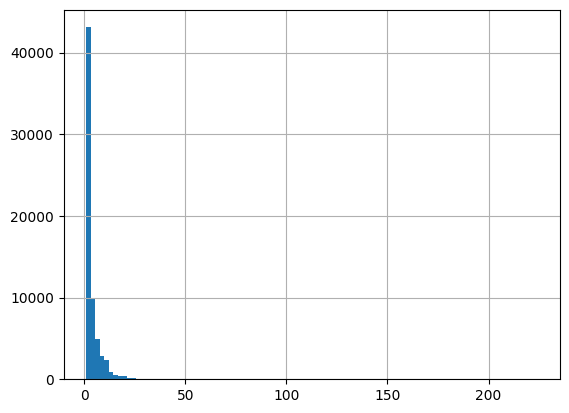

In [54]:
freq_interactions.hist(bins=100)

In [55]:
df_interaction['interaction_date'] = pd.to_datetime(df_interaction['interaction_date'])

# Calcul de la fréquence par mois
freq_par_mois = df_interaction.groupby(df_interaction['interaction_date'].dt.to_period('M')).size()
# Transformation en DataFrame transposé
freq_par_mois = pd.DataFrame(freq_par_mois).T
freq_par_mois


interaction_date,2022-12,2023-01,2023-02,2023-03,2023-04,2023-05,2023-06,2023-07,2023-08,2023-09,2023-10,2023-11
0,18525,23729,21290,24160,18824,20532,22503,18552,15592,20804,21836,25446


In [56]:
df_interaction['interaction_motif'].nunique()

34

In [57]:
df_interaction['interaction_motif'].value_counts(normalize=True) * 100

interaction_motif
Frais courants                                  15.200979
Dentaire                                        11.937584
Hospitalisation                                 10.437145
Télétransmission                                 7.670189
Médecine douce                                   7.560576
Tiers payant                                     7.185664
Optique                                          6.641567
Données administratives                          3.891689
Adhésion                                         3.859917
Modalités de règlement                           3.230034
Demande de documents                             3.139086
Résiliation                                      2.954808
Montant des cotisations                          2.684745
Demandes générales                               2.330486
Audioprothèse                                    2.096166
Cures thermales                                  1.659697
Modification de garantie                         1.647

In [58]:
(df_interaction.groupby('client_code')['interaction_motif'].nunique() == 1).sum()

np.int64(30226)

<Axes: >

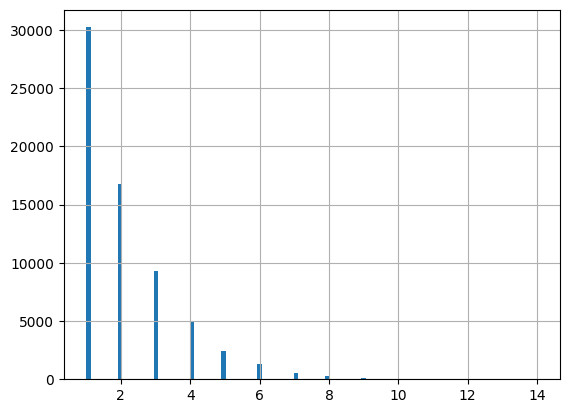

In [59]:
nb_motifs_differents = (
    df_interaction.groupby('client_code')['interaction_motif']
    .nunique()
)
nb_motifs_differents.hist(bins=100)


In [60]:
df_interaction['interaction_precision'].nunique()

101

### MéTHODE D'AGGREGATION : les interactions 
✔️ Motif le plus fréquent
✔️ Canal dominant
✔️ Service dominant
✔️ Flags majoritaires
✔️ Concaténation des textes mail
✔️ Première date d’interaction
✔️ Dernière date d’interaction
✔️ Nombre total d’interactions
✔️ Nombre de motifs différents
✔️ Nombre de canaux différents
✔️ Nombre de services différents

In [61]:
# -------------------------------
# 1. Définition des variables par type
# -------------------------------

vars_categorielles = [
    'interaction_motif',
    'interaction_precision',
    'interaction_canal',
    'interaction_service'
]

vars_flags = [
    'interaction_est_transferee_service_reclamation',
    'interaction_est_transferee_service_gestion',
    'interaction_est_transferee_service_commercial',
    'interaction_est_externalisee'
]

var_texte = 'interaction_texte_mail'
var_date  = 'interaction_date'


In [62]:
# -------------------------------
# 2. Fonctions d’agrégation
# -------------------------------

def mode_serie(s):
    """Retourne la modalité la plus fréquente."""
    return s.mode().iloc[0] if not s.mode().empty else None

def concatener_textes(s):
    """Concatène tous les textes non nuls en un seul paragraphe."""
    return " ".join(s.dropna().astype(str))

# Pour renommer proprement les colonnes multi-index après agg()
def flatten_columns(df):
    df.columns = [
        "_".join(col).strip() if isinstance(col, tuple) else col 
        for col in df.columns
    ]
    return df

In [63]:
# -------------------------------
# 3. Construction du dictionnaire d’agrégation
# -------------------------------

agg_dict = {}

# Catégorielles → mode
for col in vars_categorielles:
    agg_dict[col] = mode_serie

# Flags → mode (0 ou 1 majoritaire)
for col in vars_flags:
    agg_dict[col] = mode_serie

# Texte → concaténation
agg_dict[var_texte] = concatener_textes

# Dates → min et max
agg_dict[var_date] = ['min', 'max']

In [ ]:
# -------------------------------
# 4. Agrégation client-level
# -------------------------------

df_client = (
    df_interaction
    .groupby('client_code')
    .agg(agg_dict)
)

df_client = flatten_columns(df_client)
df_client.head(5)

,interaction_motif_mode_serie,interaction_precision_mode_serie,interaction_canal_mode_serie,interaction_service_mode_serie,interaction_est_transferee_service_reclamation_mode_serie,interaction_est_transferee_service_gestion_mode_serie,interaction_est_transferee_service_commercial_mode_serie,interaction_est_externalisee_mode_serie,interaction_texte_mail_concatener_textes,interaction_date_min,interaction_date_max
client_code,,,,,,,,,,,
22037,Décès,"Explications (procédures, garanties)",E-mail,Prestations prévoyance,0,0,0,0,xxpj0 xxobj Adhérent 3148 Mme flag_nom_ xxc...,2023-01-23,2023-01-24
22331,Demandes générales,Demande de document - Relevé de prestations,Téléphone,Prestations santé,0,0,0,1,,2023-02-13,2023-11-03
22702,Hospitalisation,Demande de document - Devis,Téléphone,Prestations santé,0,0,0,1,,2023-01-03,2023-05-10
23003,Frais courants,"Explication (prestations, devis, indu)",Téléphone,Prestations santé,0,0,0,1,,2023-01-20,2023-01-20
23164,Audioprothèse,Demande de document - Autre,Téléphone,Prestations santé,0,1,0,1,,2023-01-06,2023-05-15
...,...,...,...,...,...,...,...,...,...,...,...
16201438,Télétransmission,Attestation carte RO,E-mail,Suivi du contrat,0,1,0,0,xxpj0 Capture d’écran 2023-11-29 à 11.25.01 ...,2023-11-29,2023-11-29
16201746,Télétransmission,Attestation carte RO,E-mail,Suivi du contrat,0,1,0,0,xxpj0 AttestationDroits xxobj Attestation de d...,2023-11-29,2023-11-29
16201837,Adhésion,Process d'adhésion,E-mail,Suivi du contrat,0,1,0,0,xxpj0 Demande mutuelle flag_nom_ xxobj Demand...,2023-11-28,2023-11-28


In [ ]:
df_client.columns = (
    df_client.columns
    .str.replace('_mode_serie', '', regex=False)
    .str.replace('_concatener_textes', '', regex=False)
)
df_client.head()

,interaction_motif,interaction_precision,interaction_canal,interaction_service,interaction_est_transferee_service_reclamation,interaction_est_transferee_service_gestion,interaction_est_transferee_service_commercial,interaction_est_externalisee,interaction_texte_mail,interaction_date_min,interaction_date_max
client_code,,,,,,,,,,,
22037,Décès,"Explications (procédures, garanties)",E-mail,Prestations prévoyance,0,0,0,0,xxpj0 xxobj Adhérent 3148 Mme flag_nom_ xxc...,2023-01-23,2023-01-24
22331,Demandes générales,Demande de document - Relevé de prestations,Téléphone,Prestations santé,0,0,0,1,,2023-02-13,2023-11-03
22702,Hospitalisation,Demande de document - Devis,Téléphone,Prestations santé,0,0,0,1,,2023-01-03,2023-05-10
23003,Frais courants,"Explication (prestations, devis, indu)",Téléphone,Prestations santé,0,0,0,1,,2023-01-20,2023-01-20
23164,Audioprothèse,Demande de document - Autre,Téléphone,Prestations santé,0,1,0,1,,2023-01-06,2023-05-15
...,...,...,...,...,...,...,...,...,...,...,...
16201438,Télétransmission,Attestation carte RO,E-mail,Suivi du contrat,0,1,0,0,xxpj0 Capture d’écran 2023-11-29 à 11.25.01 ...,2023-11-29,2023-11-29
16201746,Télétransmission,Attestation carte RO,E-mail,Suivi du contrat,0,1,0,0,xxpj0 AttestationDroits xxobj Attestation de d...,2023-11-29,2023-11-29
16201837,Adhésion,Process d'adhésion,E-mail,Suivi du contrat,0,1,0,0,xxpj0 Demande mutuelle flag_nom_ xxobj Demand...,2023-11-28,2023-11-28


In [76]:
# -------------------------------
# 5. Ajout de features supplémentaires
# -------------------------------

# Nombre total d’interactions par client
df_client['nb_interactions_total'] = (
    df_interaction.groupby('client_code').size()
)

# Nombre de motifs différents
df_client['nb_motifs_differents'] = (
    df_interaction.groupby('client_code')['interaction_motif']
    .nunique()
)

# Nombre de canaux différents
df_client['nb_canaux_differents'] = (
    df_interaction.groupby('client_code')['interaction_canal']
    .nunique()
)

# Nombre de services différents
df_client['nb_services_differents'] = (
    df_interaction.groupby('client_code')['interaction_service']
    .nunique()
)

In [7]:
# -------------------------------
# 6. Résultat final : table client-level
# -------------------------------

df_client_interaction = df_client
df_client_interaction = df_client_interaction.reset_index()

df_client_interaction.head()

NameError: name 'df_client' is not defined

In [3]:
df_impayes = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_impayes_2023_11.csv", sep=";")
df_impayes.head()

,client_code,impaye_numero_dossier,impaye_type_action,impaye_date_debut_action,impaye_date_fin_action,impaye_montant_cotisation_impayee
0,14754048,2107721222,Mise en demeure,2023-02-03,2023-02-09,250.95
1,14754048,2107721222,2ème Impayé,2023-01-19,2023-02-02,235.95
2,14563067,2080438223,Annonce du contentieux,2022-12-09,2023-01-03,140.00
3,14563067,2080438223,Suspension de garanties,2022-12-02,2022-12-08,140.00
4,12629114,1804159223,Annonce du contentieux,2022-12-09,2023-02-06,254.04


In [5]:
df_impayes.shape

(15587, 6)

In [16]:
freq_impayes = df_impayes.groupby('client_code').size()
freq_impayes.describe()

count    7167.000000
mean        2.174829
std         1.768721
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max        14.000000
dtype: float64

In [67]:
# instantiate the df_conso_brut DataFrame
df_consommation = pd.read_csv("s3://projet-bdc-data/alptis/training/apprentissage_consommations_2023_11.csv", sep=";")
df_consommation.head()

,client_code,annee_mois_paiement,nb_decomptes,nb_decomptes_hospitalisation,nb_decomptes_soins_medicaux,nb_decomptes_pharmacie,nb_decomptes_optique,nb_decomptes_dentaire,nb_decomptes_divers,nb_jours_forfait_journalier,...,frais_reels_optique,frais_reels_dentaire,frais_reels_divers,reste_a_charge,reste_a_charge_hospitalisation,reste_a_charge_soins_medicaux,reste_a_charge_pharmacie,reste_a_charge_optique,reste_a_charge_dentaire,reste_a_charge_divers
0,21736,2022-12,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00
1,22037,2022-12,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00
2,22331,2022-12,10.0,0.0,4.0,6.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00
3,22604,2022-12,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,89.56,50.32,0.0,26.5,0.0,0.0,0.0,23.82
4,22702,2022-12,3.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.00,24.00,0.0,24.0,0.0,0.0,0.0,0.00


In [68]:
df_consommation.shape

(917832, 40)

In [69]:
df_consommation['client_code'].nunique()

120907

In [70]:
# Nombre de lignes dupliquées sur la combinaison (client_code, annee_mois_paiement)
df_consommation.duplicated(subset=['client_code', 'annee_mois_paiement']).sum()

np.int64(0)

In [71]:
# Vérification pour chaque ligne
verif = (
    df_consommation['nb_decomptes'] ==
    df_consommation[['nb_decomptes_hospitalisation',
                     'nb_decomptes_soins_medicaux',
                     'nb_decomptes_pharmacie',
                     'nb_decomptes_optique',
                     'nb_decomptes_dentaire',
                     'nb_decomptes_divers']].sum(axis=1)
)

# Résultats demandés
tout_est_ok = verif.all()
nombre_incoherences = (~verif).sum()
tout_est_ok, nombre_incoherences

(np.True_, np.int64(0))